In [ ]:
%pip install  spacy  en_core_web_sm
%pip install  spacy  fr_core_news_sm

     ---------------------------------------- 1.8/1.8 MB 22.3 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 22.3
    Uninstalling pip-22.3:
      Successfully uninstalled pip-22.3
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [5]:
import pandas as pd

In [17]:
patch="Data\customer_support_tickets.csv"
df=pd.read_csv(patch)

<>:1: SyntaxWarning: invalid escape sequence '\c'
<>:1: SyntaxWarning: invalid escape sequence '\c'
C:\Users\gerar\AppData\Local\Temp\ipykernel_26568\2998575440.py:1: SyntaxWarning: invalid escape sequence '\c'
  patch="Data\customer_support_tickets.csv"


In [7]:
#Valeur manquante par colonne
val_miss=df.isnull().sum()
#Pourcentage de valeur manquante par colonne
percent_miss=df.isnull().mean()*100


In [9]:
percent_miss

Ticket ID                        0.000000
Customer Name                    0.000000
Customer Email                   0.000000
Customer Age                     0.000000
Customer Gender                  0.000000
Product Purchased                0.000000
Date of Purchase                 0.000000
Ticket Type                      0.000000
Ticket Subject                   0.000000
Ticket Description               0.000000
Ticket Status                    0.000000
Resolution                      67.304286
Ticket Priority                  0.000000
Ticket Channel                   0.000000
First Response Time             33.286102
Time to Resolution              67.304286
Customer Satisfaction Rating    67.304286
dtype: float64

In [55]:
#Valeur unique par colonne
unique_values=df.nunique()
unique_values

Ticket_ID                       8469
Customer_Name                   8028
Customer_Email                  8320
Customer_Age                      53
Customer_Gender                    3
Product_Purchased                 42
Date_of_Purchase                 730
Ticket_Type                        5
Ticket_Subject                    16
Ticket_Description              8077
Ticket_Status                      3
Resolution                      2769
Ticket_Priority                    4
Ticket_Channel                     4
First_Response_Time             5470
Time_to_Resolution              2728
Customer_Satisfaction_Rating       5
dtype: int64

In [18]:

df.columns=df.columns.str.replace(' ','_')
df.columns

Index(['Ticket_ID', 'Customer_Name', 'Customer_Email', 'Customer_Age',
       'Customer_Gender', 'Product_Purchased', 'Date_of_Purchase',
       'Ticket_Type', 'Ticket_Subject', 'Ticket_Description', 'Ticket_Status',
       'Resolution', 'Ticket_Priority', 'Ticket_Channel',
       'First_Response_Time', 'Time_to_Resolution',
       'Customer_Satisfaction_Rating'],
      dtype='object')

In [54]:
#Suprimer les colonnes non essentielles pour l'analyse
df_cleaned=df.drop(columns=['Ticket_ID','Customer_Name','Customer_Email','Date_of_Purchase','Time_to_Resolution','First_Response_Time'])

In [57]:
df.head(5)

,Ticket_ID,Customer_Name,Customer_Email,Customer_Age,Customer_Gender,Product_Purchased,Date_of_Purchase,Ticket_Type,Ticket_Subject,Ticket_Description,Ticket_Status,Resolution,Ticket_Priority,Ticket_Channel,First_Response_Time,Time_to_Resolution,Customer_Satisfaction_Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [56]:
unique_values=df_cleaned.nunique()
unique_values

Customer_Age                      53
Customer_Gender                    3
Product_Purchased                 42
Ticket_Type                        5
Ticket_Subject                    16
Ticket_Description              8077
Ticket_Status                      3
Resolution                      2769
Ticket_Priority                    4
Ticket_Channel                     4
Customer_Satisfaction_Rating       5
dtype: int64

In [11]:
from matplotlib import pyplot as plt
import seaborn as sns

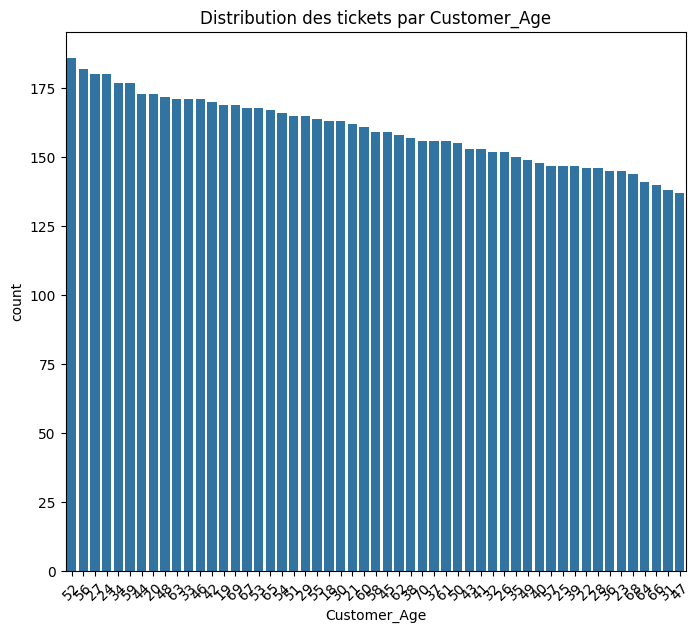

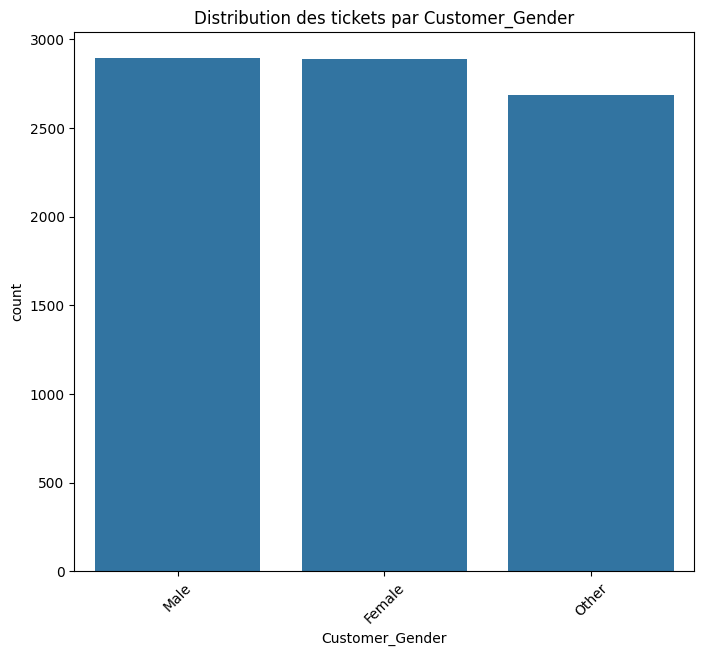

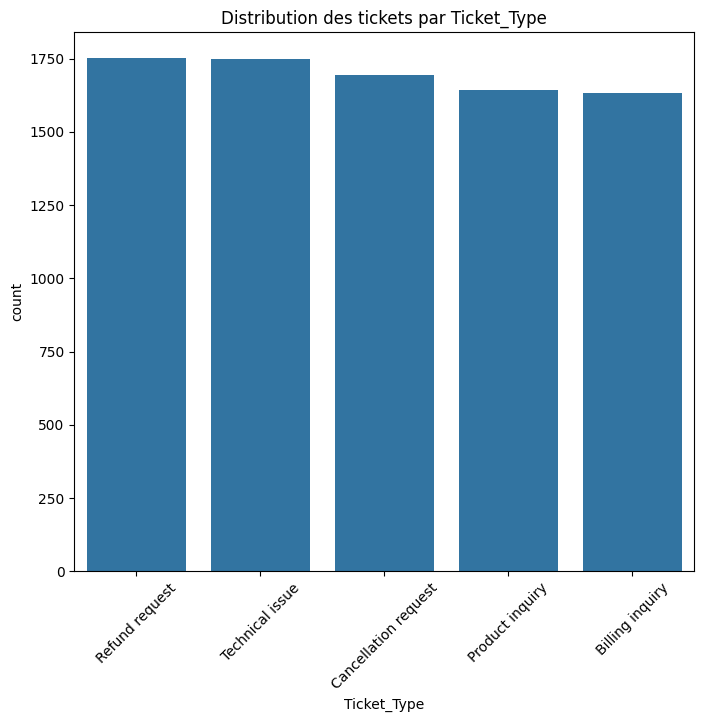

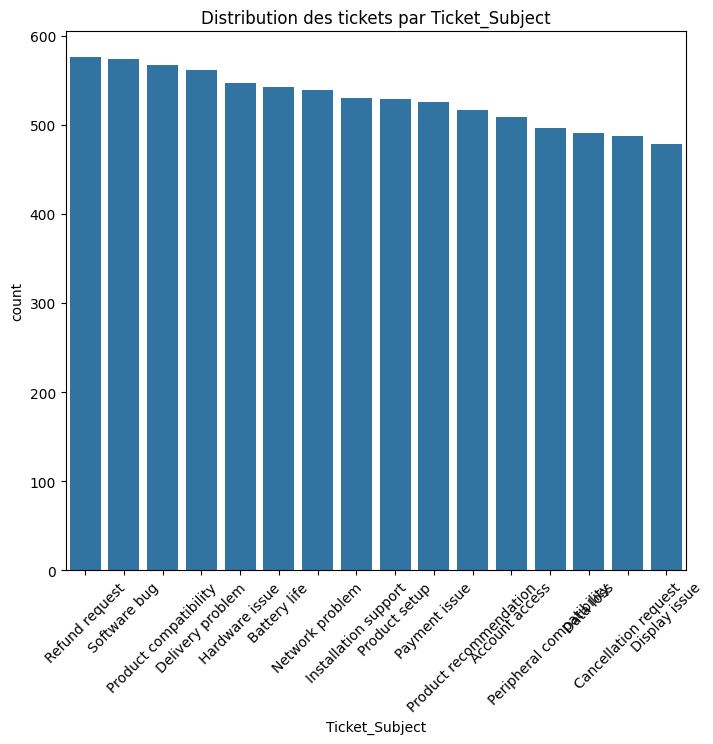

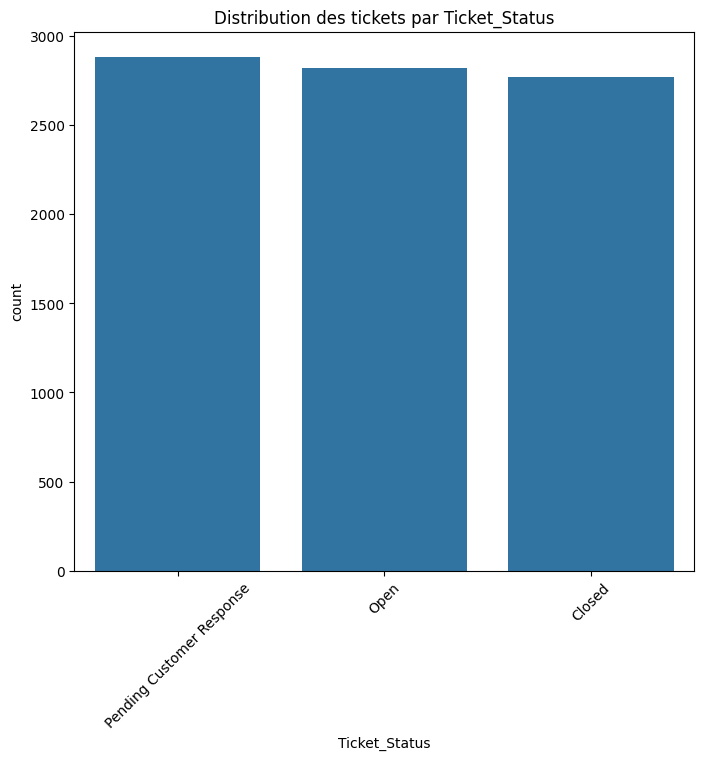

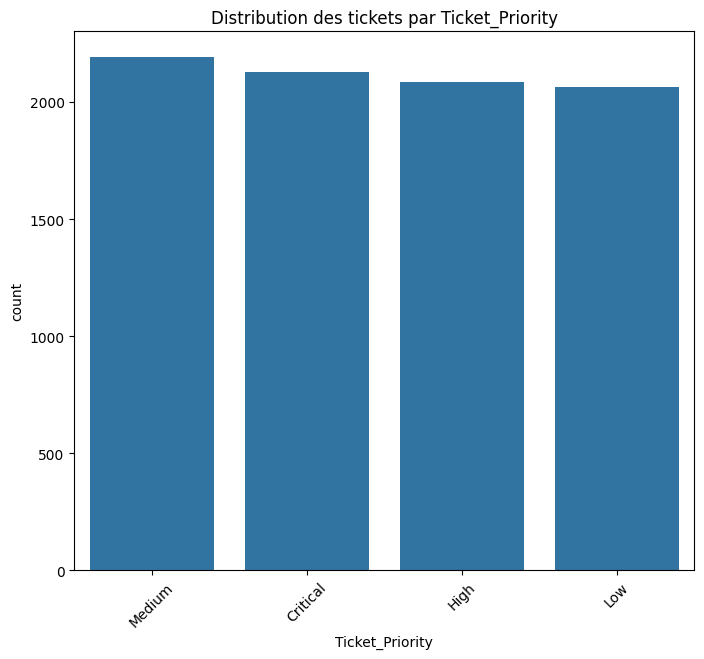

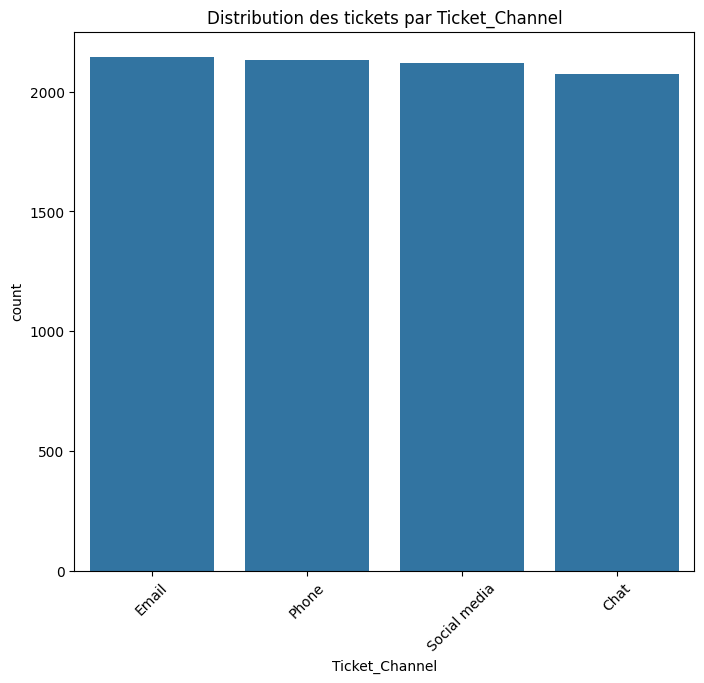

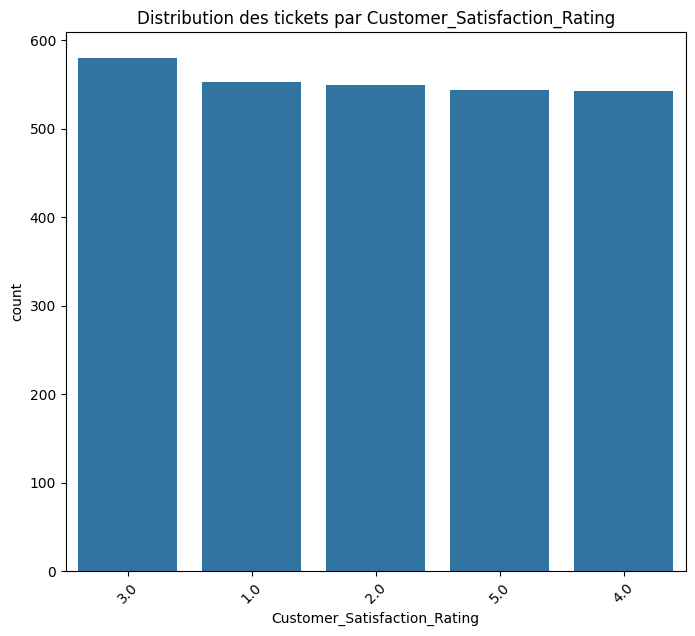

In [12]:
#Distribution des tickets par catégorie de problème
plot=['Customer_Age',
       'Customer_Gender', 'Ticket_Type', 'Ticket_Subject', 'Ticket_Status',
       'Ticket_Priority', 'Ticket_Channel',
       'Customer_Satisfaction_Rating']
for i in plot:
    plt.figure(figsize=(8,7))
    sns.countplot(data=df, x=i, order=df[i].value_counts().index)
    plt.title(f'Distribution des tickets par {i}')
    plt.xticks(rotation=45)
    plt.show()

In [ ]:
# Natural Language Processing (NLP): The ticket descriptions can be used for training NLP models to automate ticket categorization or sentiment analysis.
import spacy
from spacytextblob.spacytextblob import SpacyTextBlob
nlp_eng = spacy.load("en_core_web_sm")
nlp_fr = spacy.load("fr_core_news_sm")
nlp_eng.add_pipe('spacytextblob')
nlp_fr.add_pipe('spacytextblob')



In [36]:

def preprocess_text(text, lang='en'):
    result=[]
    if lang == 'en':
        doc = nlp_eng(text)
    else:
        doc = nlp_fr(text)
    for sentence in doc.sents:
        result.append(sentence._.blob.polarity)
        result.append(sentence._.blob.subjectivity)
    return result
df_cleaned['Polarity'] = df_cleaned.apply(lambda row: preprocess_text(row['Ticket_Description'], 'en')[0], axis=1)
df_cleaned['Subjectivity'] = df_cleaned.apply(lambda row: preprocess_text(row['Ticket_Description'], 'en')[1], axis=1)


In [37]:
df_cleaned['Polarity']

0       0.000
1       0.000
2       0.000
3       0.000
4       0.000
        ...  
8464   -0.025
8465    0.000
8466    0.000
8467    0.000
8468    0.000
Name: Polarity, Length: 8469, dtype: float64

In [38]:
df_cleaned['Subjectivity']

0       0.000
1       0.000
2       0.000
3       0.000
4       0.000
        ...  
8464    0.125
8465    0.000
8466    0.000
8467    0.000
8468    0.000
Name: Subjectivity, Length: 8469, dtype: float64

In [42]:
# apply row-wise to replace placeholder with the actual product name
df_cleaned['Ticket_Description'] = df_cleaned.apply(
	lambda x: x['Ticket_Description'].replace('{product_purchased}', x['Product_Purchased']),
	axis=1
)

In [50]:
df_cleaned.head(25)

,Customer_Age,Customer_Gender,Product_Purchased,Ticket_Type,Ticket_Subject,Ticket_Description,Ticket_Status,Resolution,Ticket_Priority,Ticket_Channel,First_Response_Time,Time_to_Resolution,Customer_Satisfaction_Rating,Processed_Description,Polarity,Subjectivity,Time_to_Resolve_Hours
0,32,Other,GoPro Hero,Technical issue,Product setup,I'm having an issue with the GoPro Hero. Pleas...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN,have issue product_purchased assist \n\n billi...,0.000000,0.000000,NaN
1,42,Female,LG Smart TV,Technical issue,Peripheral compatibility,I'm having an issue with the LG Smart TV. Plea...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN,have issue product_purchased assist \n\n need ...,0.000000,0.000000,NaN
2,48,Other,Dell XPS,Technical issue,Network problem,I'm facing a problem with my Dell XPS. The Del...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0,face problem product_purchase product_purchase...,0.000000,0.000000,6.850000
3,27,Female,Microsoft Office,Billing inquiry,Account access,I'm having an issue with the Microsoft Office....,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0,have issue product_purchased assist \n\n probl...,0.000000,0.000000,-5.533333
4,67,Female,Autodesk AutoCAD,Billing inquiry,Data loss,I'm having an issue with the Autodesk AutoCAD....,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0,have issue product_purchased assist \n\n\n not...,0.000000,0.000000,19.683333
5,53,Male,Microsoft Office,Cancellation request,Payment issue,I'm facing a problem with my Microsoft Office....,Open,NaN,Low,Social media,NaN,NaN,NaN,face problem product_purchase product_purchase...,0.000000,0.000000,NaN
6,24,Other,Microsoft Surface,Product inquiry,Refund request,I'm unable to access my Microsoft Surface acco...,Open,NaN,Critical,Social media,NaN,NaN,NaN,unable access product_purchase account keep di...,-0.500000,0.500000,NaN
7,23,Male,Philips Hue Lights,Refund request,Battery life,I'm having an issue with the Philips Hue Light...,Open,NaN,Critical,Social media,NaN,NaN,NaN,have issue product_purchased assist thank cont...,0.000000,0.000000,NaN
8,60,Other,Fitbit Versa Smartwatch,Technical issue,Installation support,I'm having an issue with the Fitbit Versa Smar...,Pending Customer Response,NaN,Low,Social media,2023-06-01 10:32:47,NaN,NaN,have issue product_purchased assist thank \n\n...,0.000000,0.000000,NaN
9,27,Male,Dyson Vacuum Cleaner,Refund request,Payment issue,My Dyson Vacuum Cleaner is making strange nois...,Pending Customer Response,NaN,Critical,Phone,2023-06-01 09:25:48,NaN,NaN,product_purchase make strange noise function p...,-0.025000,0.125000,NaN


In [45]:
#Fonction to calculate the difference in hours between two dates
def calculate_time_to_resolve(row):
    if pd.notnull(row['Time_to_Resolution']):
        time_diff = pd.to_datetime(row['Time_to_Resolution']) - pd.to_datetime(row['First_Response_Time'])
        return time_diff.total_seconds() / 3600  # Convert to hours
    else:
        return None
df_cleaned['Time_to_Resolve_Hours'] = df_cleaned.apply(calculate_time_to_resolve, axis=1)

AttributeError: 'DataFrame' object has no attribute 'dumped'

In [49]:
df_cleaned['Time_to_Resolve_Hours'].head(30)

0           NaN
1           NaN
2      6.850000
3     -5.533333
4     19.683333
5           NaN
6           NaN
7           NaN
8           NaN
9           NaN
10   -17.916667
11    -2.633333
12          NaN
13          NaN
14    -7.233333
15          NaN
16    -3.800000
17          NaN
18          NaN
19    19.716667
20          NaN
21          NaN
22          NaN
23          NaN
24          NaN
25          NaN
26          NaN
27          NaN
28     6.766667
29    17.483333
Name: Time_to_Resolve_Hours, dtype: float64